In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import json


In [3]:


folder_path = "../corpus/coref_docs_2_tag/tne_conll/"
res = []
# Loop through all files in the folder
total_num_of_sent = 0
total_num_of_mentions = 0
for filename in sorted(os.listdir(folder_path), key=lambda c: int(c.split("_")[0])):
    # Check if the file is a JSON file
    if filename.endswith('.tne'):
        # Open the file and load the JSON data
        with open(os.path.join(folder_path, filename), 'r') as file:
            json_data = json.load(file)
            file_parts = filename.strip(".tne").split("_")
            num_of_mentions = len(json_data[0]['done_nps'])

            if len(file_parts) == 5:
                doc_id = str(file_parts[4])
                print(f"{file_parts[0]}. Doc id: {file_parts[4]} ,Number of Sentences: {file_parts[1]}, Number of mentions: {num_of_mentions}")
            else:
                doc_id = f"{file_parts[4]}_{file_parts[5]}"
                print(f"{file_parts[0]}. Doc id: {file_parts[4]}_{file_parts[5]} ,Number of Sentences: {file_parts[1]}, Number of mentions: {num_of_mentions}")

            total_num_of_sent += int(file_parts[1])
            total_num_of_mentions += num_of_mentions
            res.append({"doc_id": doc_id,"sents":file_parts[1] ,"mentions": num_of_mentions})
print(f"Total num of sent: {total_num_of_sent}")
print(f"Total num of mentions: {total_num_of_mentions}")


1. Doc id: 116 ,Number of Sentences: 2, Number of mentions: 17
2. Doc id: 5 ,Number of Sentences: 3, Number of mentions: 38
3. Doc id: 96 ,Number of Sentences: 3, Number of mentions: 32
4. Doc id: 250 ,Number of Sentences: 3, Number of mentions: 13
5. Doc id: 45 ,Number of Sentences: 4, Number of mentions: 53
6. Doc id: 54 ,Number of Sentences: 4, Number of mentions: 34
7. Doc id: 79 ,Number of Sentences: 4, Number of mentions: 21
8. Doc id: 90 ,Number of Sentences: 4, Number of mentions: 34
9. Doc id: 97 ,Number of Sentences: 4, Number of mentions: 33
10. Doc id: 170 ,Number of Sentences: 4, Number of mentions: 43
11. Doc id: 187 ,Number of Sentences: 4, Number of mentions: 41
12. Doc id: 245 ,Number of Sentences: 4, Number of mentions: 82
13. Doc id: 31 ,Number of Sentences: 5, Number of mentions: 42
14. Doc id: 42 ,Number of Sentences: 5, Number of mentions: 35
15. Doc id: 44 ,Number of Sentences: 5, Number of mentions: 40
16. Doc id: 60 ,Number of Sentences: 5, Number of mentions: 

In [4]:
df = pd.DataFrame(res)

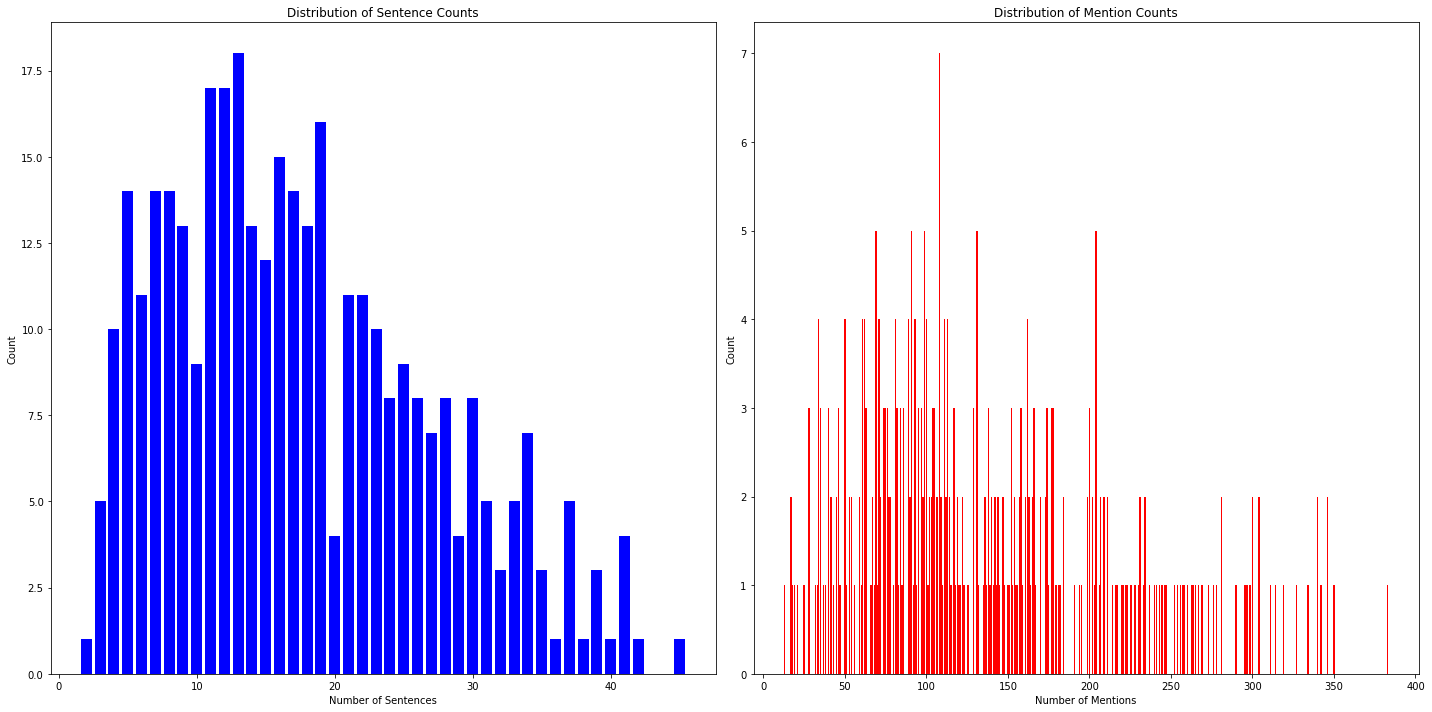

In [13]:
# Plotting the counts of sentences
sentence_length_counts = df['sents'].value_counts().sort_index().astype(int)

# Count the occurrences of each mention length
mention_length_counts = df['mentions'].value_counts().sort_index().astype(int)

# Plotting the counts
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.bar(sentence_length_counts.index.values.astype(int), sentence_length_counts.values, color='blue')
plt.xlabel('Number of Sentences')
plt.ylabel('Count')
plt.title('Distribution of Sentence Counts')

plt.subplot(1, 2, 2)
plt.bar(mention_length_counts.index.values.astype(int), mention_length_counts.values, color='red')
plt.xlabel('Number of Mentions')
plt.ylabel('Count')
plt.title('Distribution of Mention Counts')
plt.tight_layout()
plt.show()

In [12]:
df['sents'].value_counts().sort_index().astype(int)

10     9
11    17
12    17
13    18
14    13
15    12
16    15
17    14
18    13
19    16
2      1
20     4
21    11
22    11
23    10
24     8
25     9
26     8
27     7
28     8
29     4
3      5
30     8
31     5
32     3
33     5
34     7
35     3
36     1
37     5
38     1
39     3
4     10
40     1
41     4
42     1
45     1
5     14
6     11
7     14
8     14
9     13
Name: sents, dtype: int64